# Tópico 06 – Intervalos de Confiança [<img src="https://raw.githubusercontent.com/urielmoreirasilva/ICE072/main/aulas/T%C3%B3pico%2002%20%E2%80%93%20Estima%C3%A7%C3%A3o%20Pontual%20%28WLLN%29/images/colag_logo.svg" style="float: right; margin-right: 0%; vertical-align: middle; width: 6.5%;">](https://colab.research.google.com/github/urielmoreirasilva/ICE072/blob/main/aulas/T%C3%B3pico%2002%20%E2%80%93%20Estima%C3%A7%C3%A3o%20Pontual%20%28WLLN%29/T%C3%B3pico%2002%20%E2%80%93%20Estima%C3%A7%C3%A3o%20Pontual%20%28WLLN%29.ipynb) [<img src="https://raw.githubusercontent.com/urielmoreirasilva/ICE072/main/aulas/T%C3%B3pico%2002%20%E2%80%93%20Estima%C3%A7%C3%A3o%20Pontual%20%28WLLN%29/images/github_logo.svg" style="float: right; margin-right: 0%; vertical-align: middle; width: 3.25%;">](https://github.com/urielmoreirasilva/ICE072/blob/main/aulas/T%C3%B3pico%2002%20%E2%80%93%20Estima%C3%A7%C3%A3o%20Pontual%20%28WLLN%29/T%C3%B3pico%2002%20%E2%80%93%20Estima%C3%A7%C3%A3o%20Pontual%20%28WLLN%29.ipynb)




### MATERIAL EM CONSTRUÇÃO [!]

Material adaptado do [DSC10 (UCSD)](https://dsc10.com/) por [Flavio Figueiredo (DCC-UFMG)](https://flaviovdf.io/fcd/) e [Uriel Silva (DEST-UFMG)](https://urielmoreirasilva.github.io)

In [1]:
## Imports para esse tópico
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import gammaln
import math as math
plt.style.use('ggplot')

## Opções de como printar objetos do Numpy e do Pandas
np.set_printoptions(threshold = 20, precision = 2, suppress = True)
pd.set_option("display.max_rows", 7)
pd.set_option("display.max_columns", 8)
pd.set_option("display.precision", 2)

## Exemplo #1: $Poisson(\lambda)$

In [2]:
"""
Exemplo #1: Y_i ~ iid. Poisson(lambda)
"""

## Semente aleatória (para garantir reprodutibilidade)
np.random.seed(42)

## Tamanho amostral
n = int(1e3)

## Quantidade de amostras independentes
m = int(1e3)

## Parâmetros da simulação
lam = 2 # taxa da Poisson
mu = 2 # média populacional

## Declarando objetos
vY_bar = np.zeros(m)

## Loop principal
for j in np.arange(0, m, 1):
    vY = np.random.poisson(lam = lam, size = n) # gerando amostra
    vY_bar[j] = vY.mean() # calculando a média

In [3]:
## Amostra das médias
vY_bar

array([2.  , 1.98, 1.9 , ..., 1.98, 2.03, 2.02], shape=(1000,))

In [9]:
IC = [vY_bar[1] - 2*np.sqrt(lam)/np.sqrt(n), vY_bar[1] + 2*np.sqrt(lam)/np.sqrt(n)]
IC

[np.float64(1.8915572809000085), np.float64(2.070442719099992)]

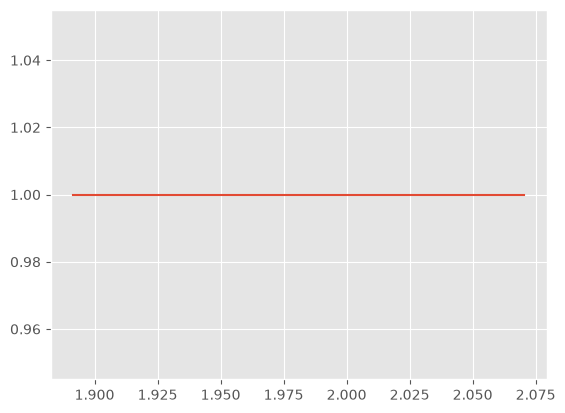

In [11]:
plt.plot(IC, [1, 1])

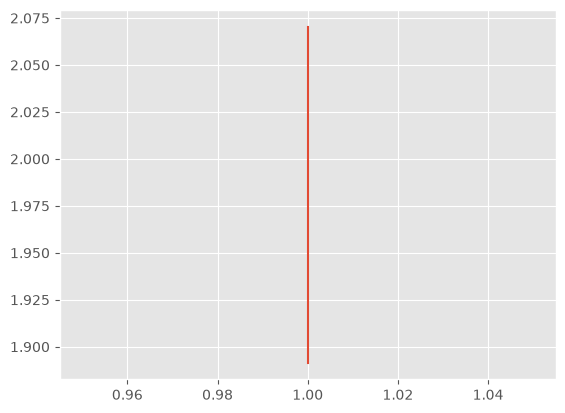

In [12]:
plt.plot([1, 1], IC)

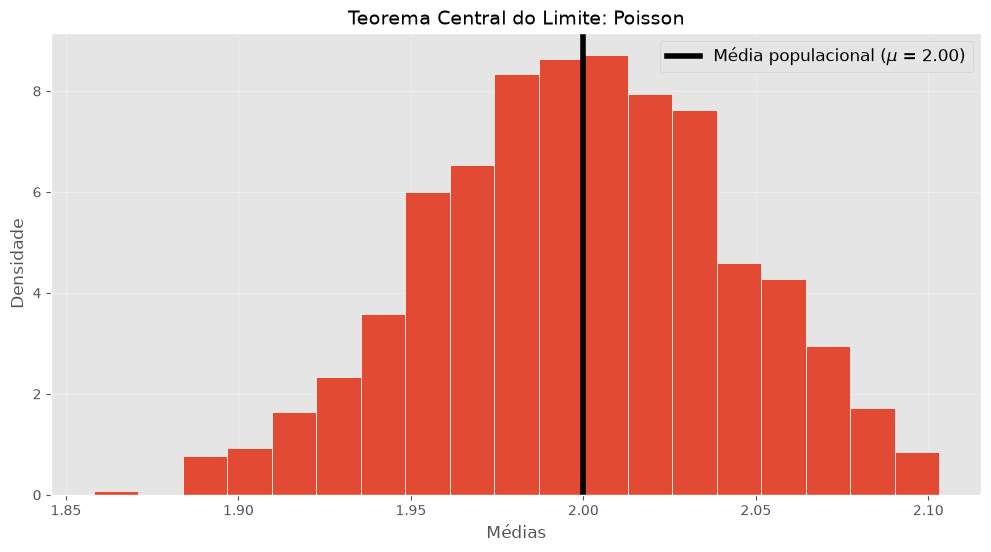

In [5]:
## Visualizando a distribuição amostral das médias
plt.figure(figsize = (12, 6))
plt.hist(vY_bar, 
         bins = np.arange(vY_bar.min(), vY_bar.max(), (vY_bar.max() - vY_bar.min())/20), 
         density = True, 
         ec = 'w')
plt.axvline(mu, color = 'black', linewidth = 4, label = f'Média populacional ($\\mu$ = {lam:.2f})')
plt.title('Teorema Central do Limite: Poisson', fontsize = 14)
plt.xlabel('Médias', fontsize = 12)
plt.ylabel('Densidade', fontsize = 12)
plt.legend(fontsize = 12)
plt.grid(True, alpha = 0.3)
plt.show()

## Exemplo #1: $Beta(\alpha, 1)$

In [5]:
"""
Exemplo #1: Y_i ~ iid. Beta(\alpha, 1)
"""

## Semente aleatória (para garantir reprodutibilidade)
np.random.seed(42)

## Tamanho amostral
n = int(1e3)

## Parâmetros da simulação
alpha = 1./2 # forma da Beta
beta = 1 # outro parâmetro de forma da Beta :)
mu = alpha / (alpha + beta) # média populacional

## Declarando objetos
vY_bar = np.zeros(m)

## Loop principal
for j in np.arange(0, m, 1):
    vY = np.random.beta(a = alpha, b = 1, size = n) # gerando amostra
    vY_bar[j] = vY.mean() # calculando a média

In [6]:
## Amostra das médias
vY_bar

array([0.32, 0.34, 0.34, ..., 0.35, 0.33, 0.35], shape=(1000,))

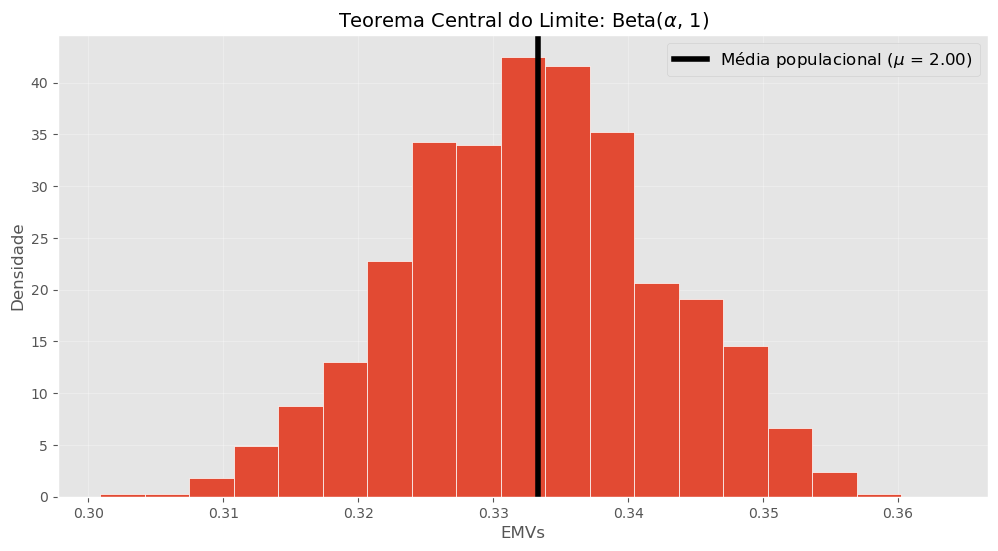

In [10]:
## Visualizando a distribuição amostral das médias
plt.figure(figsize = (12, 6))
plt.hist(vY_bar, 
         bins = np.arange(vY_bar.min(), vY_bar.max(), (vY_bar.max() - vY_bar.min())/20), 
         density = True, 
         ec = 'w')
plt.axvline(mu, color = 'black', linewidth = 4, label = f'Média populacional ($\mu$ = {lam:.2f})')
plt.title('Teorema Central do Limite: Beta($\\alpha$, 1)', fontsize = 14)
plt.xlabel('EMVs', fontsize = 12)
plt.ylabel('Densidade', fontsize = 12)
plt.legend(fontsize = 12)
plt.grid(True, alpha = 0.3)
plt.show()